# **Pract 3: Data Exploration and Ethical Analysis**
Perform basic exploratory data analysis on a dataset and identify ethical issues related to privacy, bias, and responsible data usage.

In [1]:

# Dataset: Wearable Health Lifestyle Ethics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# STEP 1: Load the Dataset
file_path = "/content/Wearable_Health_Lifestyle_Ethics.csv"
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [ ]:
# STEP 2: Basic Data Exploration
print("First 5 Records:\n")
print(df.head())

print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("Column Information:")
print(df.info())

print("Statistical Summary:")
print(df.describe())


First 5 Records:

  User_ID  Age  Gender   BMI  Daily_Steps  Avg_Sleep_Hours  \
0   U1001   56    Male  31.4        16493              6.6   
1   U1002   46  Female  21.2        18908              8.2   
2   U1003   32    Male  30.9         9224              6.6   
3   U1004   60  Female  31.6         5025              9.1   
4   U1005   25  Female  19.6        19950              5.8   

   Resting_Heart_Rate  Stress_Level  Water_Intake_Liters Smoking_Habit  \
0                  55             8                  3.8           Yes   
1                  52             3                  1.9           Yes   
2                  84             2                  0.7            No   
3                  67             7                  1.1           Yes   
4                  60             8                  4.6            No   

       Region Income_Level Health_Risk_Category  Insurance_Premium  \
0  Semi-Urban       Medium                 High           16338.10   
1  Semi-Urban       Medi

In [ ]:
# STEP 3: Missing Value Analysis
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
User_ID                        0
Age                            0
Gender                         0
BMI                            0
Daily_Steps                    0
Avg_Sleep_Hours                0
Resting_Heart_Rate             0
Stress_Level                   0
Water_Intake_Liters            0
Smoking_Habit                  0
Region                         0
Income_Level                   0
Health_Risk_Category           0
Insurance_Premium              0
Data_Shared_With_ThirdParty    0
dtype: int64


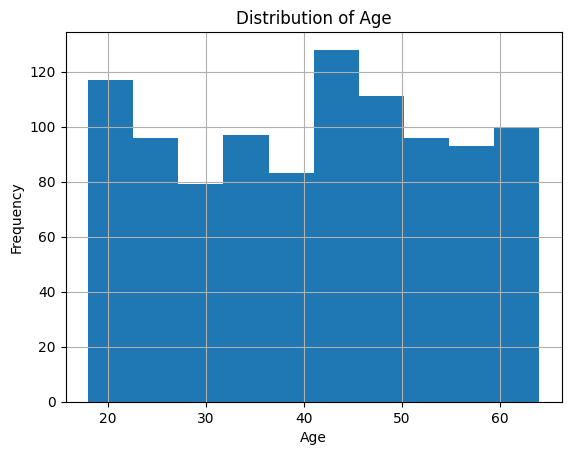

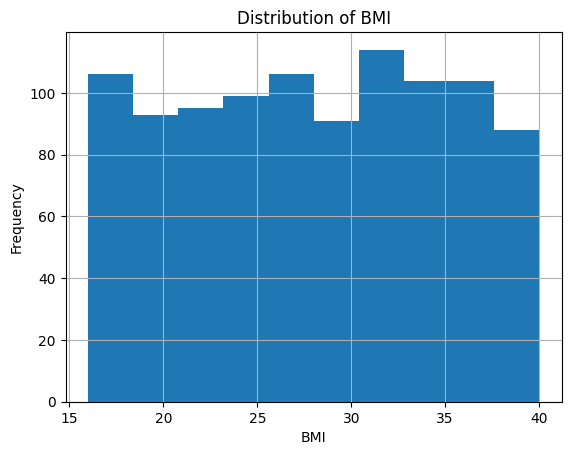

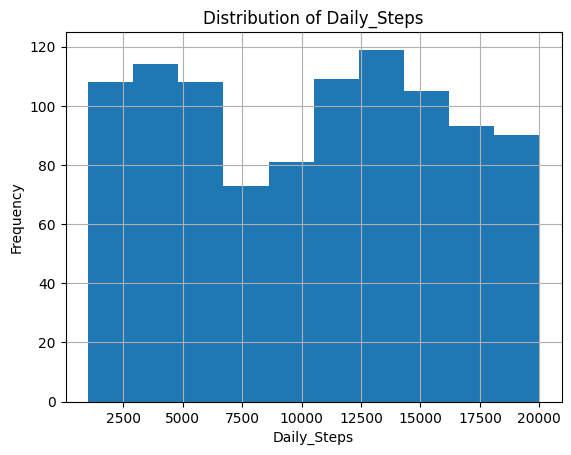

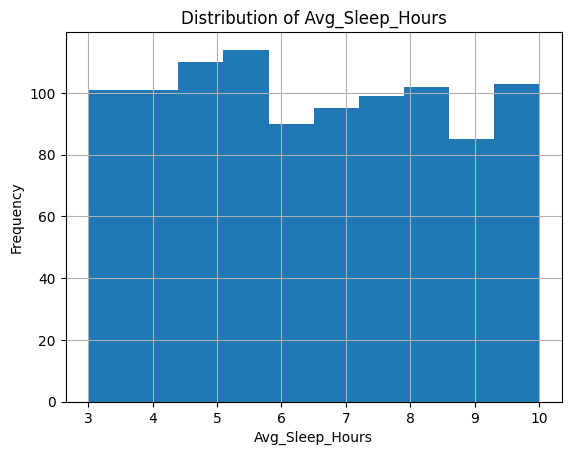

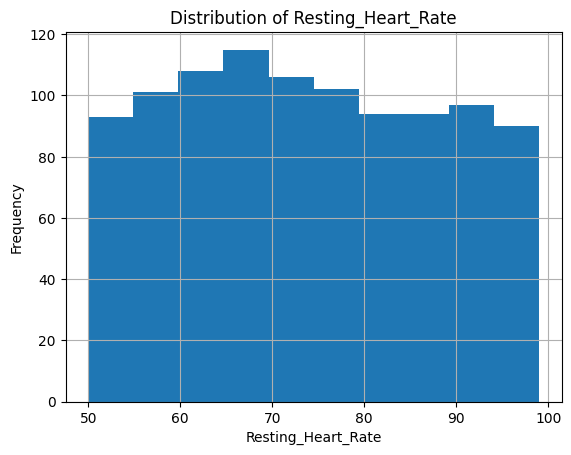

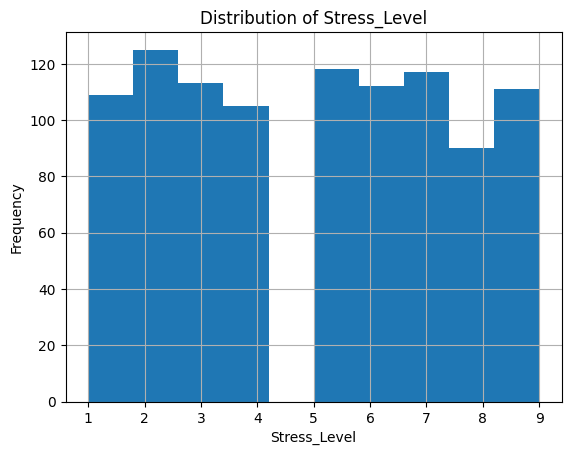

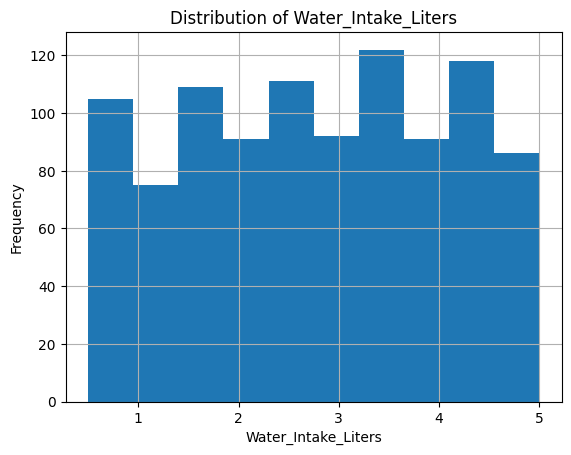

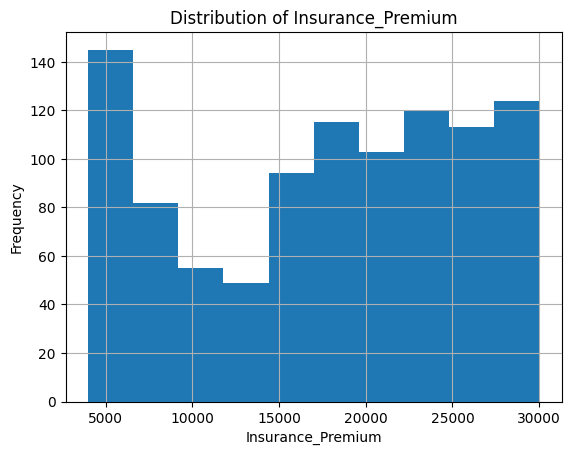

In [ ]:
# STEP 4: Visual Exploration
# Plot numeric distributions
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:

    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Correlation Matrix:
                          Age       BMI  Daily_Steps  Avg_Sleep_Hours  \
Age                  1.000000  0.024641     0.042104        -0.047440   
BMI                  0.024641  1.000000    -0.053853         0.043808   
Daily_Steps          0.042104 -0.053853     1.000000        -0.044813   
Avg_Sleep_Hours     -0.047440  0.043808    -0.044813         1.000000   
Resting_Heart_Rate  -0.023903 -0.015268    -0.023734         0.010763   
Stress_Level        -0.017191  0.022749     0.016745        -0.045019   
Water_Intake_Liters  0.009698 -0.001735     0.030804        -0.029944   
Insurance_Premium    0.049038  0.475127     0.016927        -0.008144   

                     Resting_Heart_Rate  Stress_Level  Water_Intake_Liters  \
Age                           -0.023903     -0.017191             0.009698   
BMI                           -0.015268      0.022749            -0.001735   
Daily_Steps                   -0.023734      0.016745             0.030804   
Avg_Sleep_

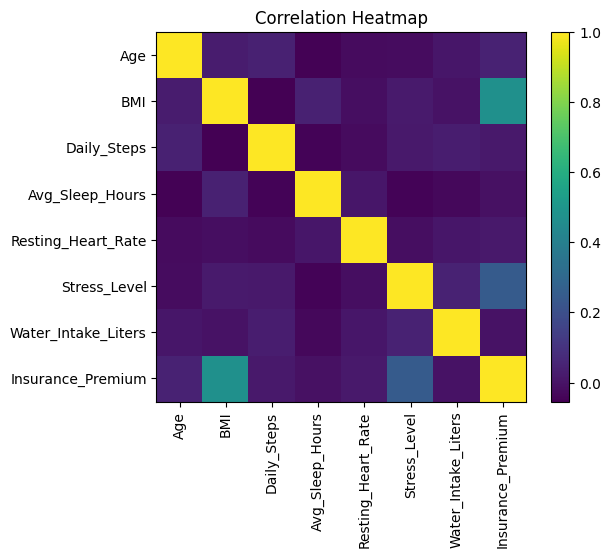

In [ ]:
# STEP 5: Correlation Analysis
print("Correlation Matrix:")
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.show()

In [ ]:
# STEP 6: Ethical Analysis Section
# Privacy Risk Detection
sensitive_keywords = ["name", "email", "phone", "address",
                      "location", "gps", "id", "dob"]
privacy_risk = []

for col in df.columns:
    for keyword in sensitive_keywords:
        if keyword.lower() in col.lower():
            privacy_risk.append(col)

if privacy_risk:
    print("PRIVACY RISK DETECTED!")
    print("Sensitive columns found:", privacy_risk)
else:
    print("No obvious direct personal identifiers detected.")


# Bias Detection (Demographic skew check)

demographic_cols = ["Gender", "Age", "Region"]

for col in demographic_cols:
    if col in df.columns:
        print(f"Distribution of {col}:")
        print(df[col].value_counts(normalize=True))


print("Ethical Concern:")
print("If one demographic group dominates the dataset,")
print("AI models trained on it may show biased predictions.")


# 3️⃣ Responsible Data Usage Check
print("Responsible Data Usage Considerations:")
print("- Was user consent taken?")
print("- Is the data anonymized?")
print("- Is the data used strictly for health improvement?")
print("- Is it shared with third parties?")


print("\n================ END OF ANALYSIS =================")

PRIVACY RISK DETECTED!
Sensitive columns found: ['User_ID']
Recommendation: Mask, anonymize, or encrypt these fields.
Distribution of Gender:
Gender
Female        0.491
Male          0.467
Non-binary    0.042
Name: proportion, dtype: float64
Distribution of Age:
Age
43    0.033
50    0.030
45    0.030
52    0.028
64    0.027
54    0.027
56    0.025
18    0.025
62    0.025
41    0.025
49    0.025
22    0.025
19    0.024
20    0.024
40    0.024
42    0.024
25    0.023
53    0.023
23    0.023
61    0.023
34    0.022
29    0.022
39    0.022
33    0.021
47    0.021
36    0.020
28    0.020
38    0.019
31    0.019
21    0.019
46    0.019
58    0.018
26    0.018
32    0.018
27    0.018
30    0.018
51    0.018
37    0.018
57    0.017
59    0.017
48    0.016
55    0.016
44    0.016
35    0.016
24    0.014
63    0.013
60    0.012
Name: proportion, dtype: float64
Distribution of Region:
Region
Urban         0.348
Rural         0.346
Semi-Urban    0.306
Name: proportion, dtype: float64
Ethical Conc